# Plan d'expérience — Recuit Simulé Multi-Start

Ce plan d'expérience suit le plan suivant :
1. Définition des paramètres globaux
2. Étude de trajectoire
3. Étude de l'influence des paramètres
4. Définition des paramètres optimisés
5. Statistiques qualité des solutions
6. Distance à la borne inférieure
7. Conclusion

## 1. Définition des paramètres globaux

Le **recuit simulé multi-start** consiste à exécuter `n_restarts` runs indépendants du recuit simulé et à retenir le meilleur tour trouvé.

**Conclusion de l'expérience précédente :** la profondeur l'emporte sur la diversification — un seul run de 1000 iter (gap ~422%) bat largement 10 runs de 100 iter. On explore donc des configurations à **peu de restarts mais beaucoup d'itérations**.

**Paramètre fixé** (d'après l'expérience mono-run) :
- `ALPHA = 0.995` — taux de refroidissement optimal identifié précédemment

**Paramètres étudiés** :
- `n_restarts` ∈ {1, 2, 5}
- `max_iter_per_restart` ∈ {1 000, 3 000, 5 000}

**Protocole** :
- $N = \{10, 12, 15, 17, 20, 22, 25, 30\}$ : tailles de graphe
- `NB_SEEDS = 10` : instances par taille
- `NB_ITERATIONS = 3` : répétitions par instance et configuration
- **Total** $= 3 \times 3 \times 8 \times 10 \times 3 = 2\,160$ exécutions

La borne inférieure « min-sortants » $\frac{1}{2}\sum_v \min_{u \neq v} w(v,u)$ sert de référence pour le gap :
$$\text{gap} = 100 \times \frac{\text{cost} - \text{reference}}{\text{reference}}$$

In [56]:
import sys
import math
import time

import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../")

from graph_generator import generate_graph
from helper import is_tour_feasible, valid_next_nodes

In [57]:
N_VALUES: list[int] = [10, 12, 15, 17, 20, 22, 25, 30]
NB_SEEDS: int = 10
NB_ITERATIONS: int = 3

# Paramètre fixé d'après l'expérience mono-run
ALPHA: float = 0.995

# Grille de paramètres à étudier
# Conclusion précédente : la profondeur l'emporte sur la diversification
# → moins de restarts, beaucoup plus d'itérations par run
N_RESTARTS_VALUES: list[int] = [1, 2, 5]
MAX_ITER_PER_RESTART_VALUES: list[int] = [1000, 3000, 5000]


def get_standard_instances(n: int, nb_seeds: int = NB_SEEDS) -> list[tuple[int, nx.Graph]]:
    instances: list[tuple[int, nx.Graph]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        instances.append((seed, graph))
    return instances

In [58]:
def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, reference: float) -> float:
    if reference <= 0:
        return float("inf")
    return 100.0 * (cost - reference) / reference


instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in N_VALUES:
    raw = get_standard_instances(n)
    enriched = [(seed, graph, reference_value(graph)) for seed, graph in raw]
    instances[n] = enriched
    refs = [r for _, _, r in enriched]
    print(f"N={n:3d} | {len(enriched)} instances | ref min={min(refs):.2f} max={max(refs):.2f}")

N= 10 | 10 instances | ref min=8.10 max=18.52
N= 12 | 10 instances | ref min=8.10 max=20.10
N= 15 | 10 instances | ref min=7.65 max=17.25
N= 17 | 10 instances | ref min=7.05 max=16.80
N= 20 | 10 instances | ref min=7.58 max=16.87
N= 22 | 10 instances | ref min=5.40 max=15.07
N= 25 | 10 instances | ref min=6.38 max=15.90
N= 30 | 10 instances | ref min=7.65 max=12.30


## 2. Étude de trajectoire

Objectif : visualiser la dynamique du recuit simulé multi-start — comment le meilleur coût global s'améliore au fil des restarts successifs (effet « escalier descendant »).

On trace la trajectoire pour une instance représentative ($N = 20$, `seed=0`) avec différents nombres de restarts, puis on compare les trajectoires pour 4 tailles de graphe.

In [59]:
# ── Implémentation inlinée du recuit (évite les imports relatifs du package) ──

def _tour_cost(graph: nx.Graph, tour: list[int]) -> float:
    total: float = 0.0
    for u, v in zip(tour, tour[1:]):
        weight: float = graph.edges[u, v]["weight"]
        if weight == -1:
            return float("inf")
        total += weight
    return total


def _is_feasible(graph: nx.Graph, tour: list[int]) -> bool:
    if len(tour) < 2 or tour[0] != tour[-1]:
        return False
    open_tour: list[int] = tour[:-1]
    if len(set(open_tour)) != len(open_tour):
        return False
    return is_tour_feasible(graph, open_tour)


def _two_opt_swap(tour: list[int], i: int, j: int) -> list[int]:
    return tour[:i] + tour[i:j + 1][::-1] + tour[j + 1:]


def _initial_tour(graph: nx.Graph, rng: np.random.Generator) -> list[int]:
    n: int = graph.number_of_nodes()
    visited: set[int] = {0}
    tour: list[int] = [0]
    while len(tour) < n:
        current: int = tour[-1]
        candidates: list[int] = valid_next_nodes(graph, current, visited)
        if not candidates:
            break
        next_node = min(candidates, key=lambda v: graph.edges[current, v]["weight"])
        tour.append(next_node)
        visited.add(next_node)
    tour.append(0)
    if _is_feasible(graph, tour):
        return tour
    for _ in range(50):
        order: list[int] = list(range(1, n))
        rng.shuffle(order)
        candidate: list[int] = [0] + order + [0]
        if _is_feasible(graph, candidate):
            return candidate
    return [0] + list(range(1, n)) + [0]


def _initial_temperature(graph: nx.Graph, tour: list[int], rng: np.random.Generator) -> float:
    n: int = len(tour)
    base_cost: float = _tour_cost(graph, tour)
    degradations: list[float] = []
    for _ in range(n * 20):
        i = int(rng.integers(1, n - 2))
        j = int(rng.integers(i + 1, n - 1))
        neighbor = _two_opt_swap(tour, i, j)
        if not _is_feasible(graph, neighbor):
            continue
        delta = _tour_cost(graph, neighbor) - base_cost
        if delta > 0:
            degradations.append(delta)
        if len(degradations) >= 100:
            break
    if not degradations:
        return 1.0
    return -float(np.mean(degradations)) / math.log(0.8)


def resolve_by_recuit_simule(
    graph: nx.Graph,
    max_iterations: int = 10000,
    seed: int | None = None,
    alpha: float = 0.995,
) -> tuple[list[int], float]:
    rng = np.random.default_rng(seed)
    current = _initial_tour(graph, rng)
    current_cost = _tour_cost(graph, current)
    best = list(current)
    best_cost = current_cost
    t = _initial_temperature(graph, current, rng)
    n = len(current)
    for _ in range(max_iterations):
        neighbor = None
        for _ in range(100):
            i = int(rng.integers(1, n - 2))
            j = int(rng.integers(i + 1, n - 1))
            candidate = _two_opt_swap(current, i, j)
            if _is_feasible(graph, candidate):
                neighbor = candidate
                break
        if neighbor is None:
            break
        delta = _tour_cost(graph, neighbor) - current_cost
        if delta <= 0 or rng.random() < math.exp(-delta / t):
            current = neighbor
            current_cost += delta
            if current_cost < best_cost:
                best = list(current)
                best_cost = current_cost
        t *= alpha
    return best, best_cost


def resolve_by_ms_recuit_simule(
    graph: nx.Graph,
    n_restarts: int = 5,
    max_iterations_per_restart: int = 1000,
    seed: int | None = None,
    alpha: float = 0.995,
) -> tuple[list[int], float]:
    rng = np.random.default_rng(seed)
    best: list[int] = []
    best_cost: float = float("inf")
    for _ in range(n_restarts):
        tour, cost = resolve_by_recuit_simule(
            graph,
            max_iterations=max_iterations_per_restart,
            seed=int(rng.integers(0, 2**31)),
            alpha=alpha,
        )
        if cost < best_cost:
            best = tour
            best_cost = cost
    return best, best_cost


def resolve_by_ms_recuit_simule_traced(
    graph: nx.Graph,
    n_restarts: int,
    max_iterations_per_restart: int,
    seed: int | None,
    alpha: float,
) -> tuple[list[int], float, list[float]]:
    """Variante instrumentée : renvoie l'historique du meilleur coût après chaque restart."""
    rng = np.random.default_rng(seed)
    best: list[int] = []
    best_cost: float = float("inf")
    history: list[float] = []
    for _ in range(n_restarts):
        tour, cost = resolve_by_recuit_simule(
            graph,
            max_iterations=max_iterations_per_restart,
            seed=int(rng.integers(0, 2**31)),
            alpha=alpha,
        )
        if cost < best_cost:
            best = tour
            best_cost = cost
        history.append(best_cost)
    return best, best_cost, history

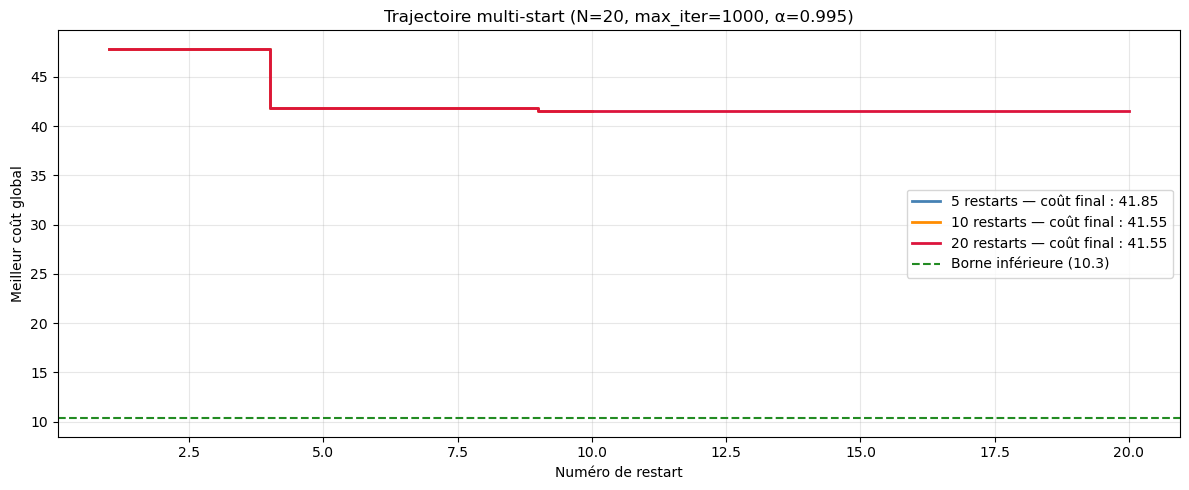

In [60]:
# Trajectoire pour N=20 : comparaison de différents n_restarts
TRACE_N = 20
TRACE_SEED = 0
TRACE_MAX_ITER = 1000
TRACE_RESTARTS_LIST = [5, 10, 20]
COLORS = ["steelblue", "darkorange", "crimson"]

_, trace_graph, trace_ref = instances[TRACE_N][TRACE_SEED]

fig, ax = plt.subplots(figsize=(12, 5))

for n_r, color in zip(TRACE_RESTARTS_LIST, COLORS):
    _, best_cost, history = resolve_by_ms_recuit_simule_traced(
        trace_graph, n_restarts=n_r,
        max_iterations_per_restart=TRACE_MAX_ITER,
        seed=2026, alpha=ALPHA,
    )
    ax.step(
        range(1, n_r + 1), history,
        where="post", linewidth=2, color=color,
        label=f"{n_r} restarts — coût final : {best_cost:.2f}",
    )

ax.axhline(trace_ref, color="forestgreen", linestyle="--",
           linewidth=1.5, label=f"Borne inférieure ({trace_ref:.1f})")
ax.set_xlabel("Numéro de restart")
ax.set_ylabel("Meilleur coût global")
ax.set_title(f"Trajectoire multi-start (N={TRACE_N}, max_iter={TRACE_MAX_ITER}, α={ALPHA})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Comparaison des trajectoires pour différentes tailles

Trajectoires multi-start pour 4 tailles représentatives ($N \in \{10, 15, 20, 30\}$), avec `n_restarts=10`. L'effet escalier est d'autant plus marqué que le problème est difficile (grand $N$).

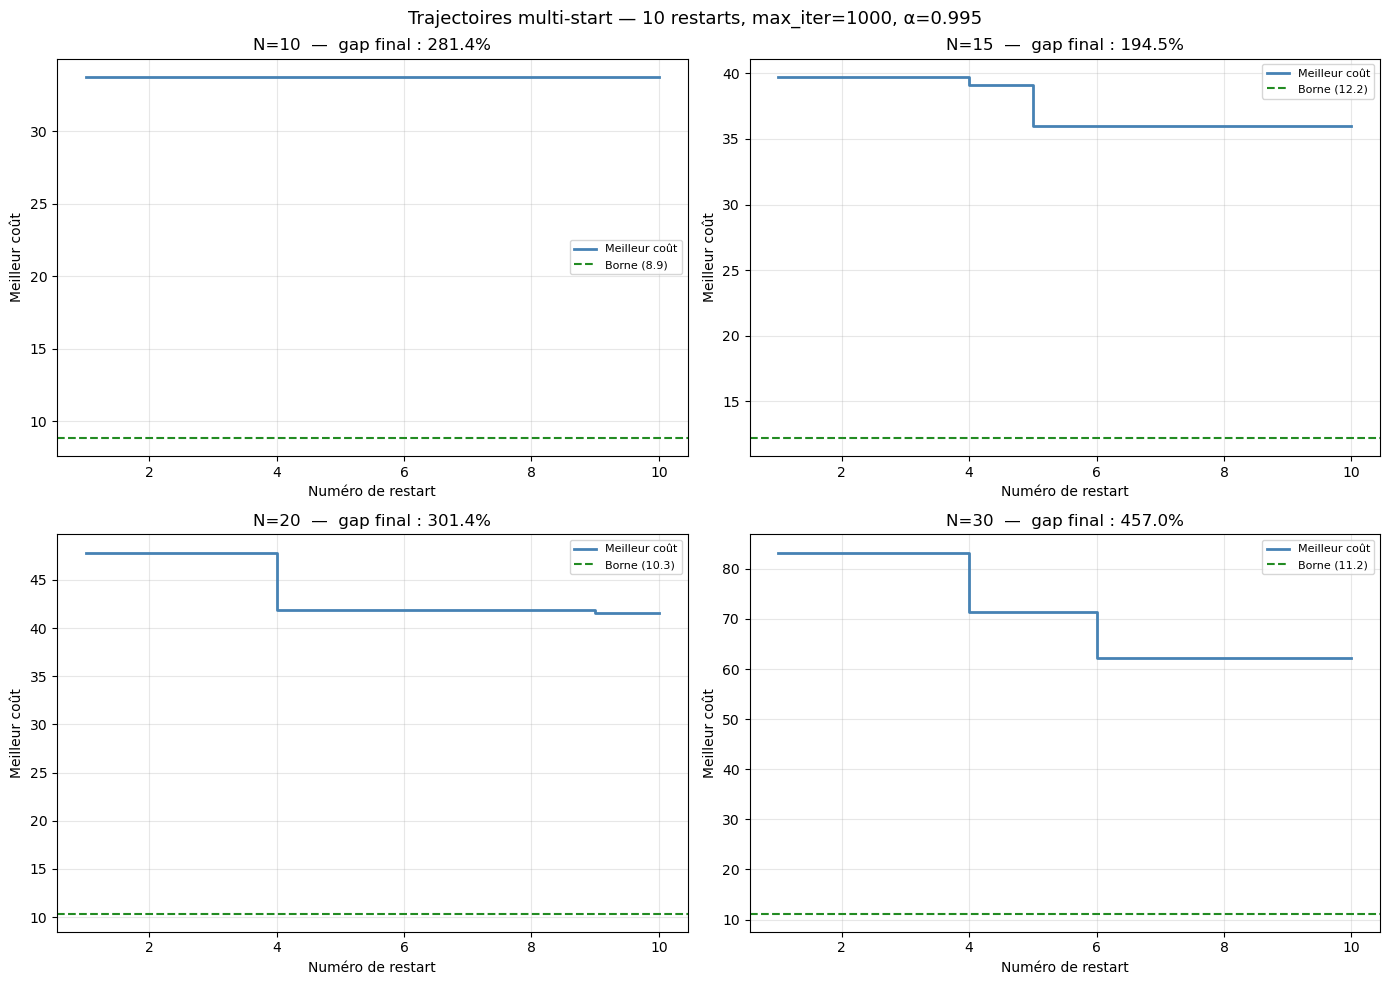

In [61]:
MULTI_N_SIZES = [10, 15, 20, 30]
MULTI_N_RESTARTS = 10
MULTI_MAX_ITER = 1000

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, n in zip(axes, MULTI_N_SIZES):
    _, graph, ref = instances[n][0]
    _, best_cost, history = resolve_by_ms_recuit_simule_traced(
        graph, n_restarts=MULTI_N_RESTARTS,
        max_iterations_per_restart=MULTI_MAX_ITER,
        seed=2026, alpha=ALPHA,
    )
    gap_final = compute_gap(best_cost, ref)
    ax.step(range(1, MULTI_N_RESTARTS + 1), history, where="post",
            color="steelblue", linewidth=2, label="Meilleur coût")
    ax.axhline(ref, color="forestgreen", linestyle="--",
               linewidth=1.5, label=f"Borne ({ref:.1f})")
    ax.set_title(f"N={n}  —  gap final : {gap_final:.1f}%")
    ax.set_xlabel("Numéro de restart")
    ax.set_ylabel("Meilleur coût")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Trajectoires multi-start — {MULTI_N_RESTARTS} restarts, max_iter={MULTI_MAX_ITER}, α={ALPHA}",
    fontsize=13,
)
plt.tight_layout()
plt.show()

### Interprétation

L'effet « escalier descendant » est visible sur toutes les tailles : chaque restart offre une nouvelle chance d'améliorer le meilleur coût global. Pour **N=10**, le coût converge rapidement en 2–3 restarts — l'espace de recherche est petit. Pour **N=30**, les marches restent espacées tout au long des 10 restarts, signe que l'espace est plus difficile à explorer et que la diversification apporte un bénéfice durable.

La borne inférieure (ligne verte) reste éloignée des coûts obtenus sur toutes les tailles : cela reflète la nature non-serrée de la borne « min-sortants » sur des instances fortement contraintes (précédence + arêtes interdites).

## 3. Étude de l'influence des paramètres

Objectif : mesurer l'impact de `n_restarts` et `max_iter_per_restart` sur le gap (%) moyen. D'après l'expérience précédente, la **profondeur l'emporte sur la diversification** — on réduit donc le nombre de restarts et on augmente les itérations par run.

**Grille testée :**
- `n_restarts` ∈ {1, 2, 5} — moins de diversification
- `max_iter_per_restart` ∈ {1 000, 3 000, 5 000} — plus de profondeur
- `alpha` = 0.995 (fixé)

**Total** $= 3 \times 3 \times 8 \times 10 \times 3 = 2\,160$ exécutions.

> ⚠️ Durée estimée : **20–40 min** selon la machine (le cas `5 × 5000` sur N=30 est le plus coûteux).

In [62]:
GLOBAL_SEED = 12345

grid_records: list[dict] = []
total_runs = (
    len(N_RESTARTS_VALUES) * len(MAX_ITER_PER_RESTART_VALUES)
    * sum(len(instances[n]) for n in N_VALUES) * NB_ITERATIONS
)
runs_done = 0
t_start = time.perf_counter()

for n in N_VALUES:
    for n_restarts in N_RESTARTS_VALUES:
        for max_iter_pr in MAX_ITER_PER_RESTART_VALUES:
            for instance_seed, graph, ref in instances[n]:
                for run_k in range(NB_ITERATIONS):
                    algo_seed = GLOBAL_SEED + instance_seed * 1000 + run_k
                    t0 = time.perf_counter()
                    tour, cost = resolve_by_ms_recuit_simule(
                        graph=graph,
                        n_restarts=n_restarts,
                        max_iterations_per_restart=max_iter_pr,
                        seed=algo_seed,
                        alpha=ALPHA,
                    )
                    elapsed = time.perf_counter() - t0
                    feasible = _is_feasible(graph, tour) if tour else False
                    gap = compute_gap(cost, ref) if cost != float("inf") else float("inf")
                    grid_records.append({
                        "N": n,
                        "n_restarts": n_restarts,
                        "max_iter_pr": max_iter_pr,
                        "instance_seed": instance_seed,
                        "run": run_k,
                        "cost": cost,
                        "gap": gap,
                        "feasible": feasible,
                        "time_sec": elapsed,
                    })
                    runs_done += 1
    print(f"N={n:3d} terminé ({runs_done}/{total_runs} runs, {time.perf_counter() - t_start:.1f}s)")

grid_df = pd.DataFrame(grid_records)
print(f"\nTotal : {len(grid_df)} runs en {time.perf_counter() - t_start:.1f}s")
grid_df.head()

N= 10 terminé (270/2160 runs, 93.4s)
N= 12 terminé (540/2160 runs, 188.0s)
N= 15 terminé (810/2160 runs, 305.8s)
N= 17 terminé (1080/2160 runs, 436.1s)
N= 20 terminé (1350/2160 runs, 586.1s)
N= 22 terminé (1620/2160 runs, 736.5s)
N= 25 terminé (1890/2160 runs, 908.5s)
N= 30 terminé (2160/2160 runs, 1116.5s)

Total : 2160 runs en 1116.5s


,N,n_restarts,max_iter_pr,instance_seed,run,cost,gap,feasible,time_sec
0,10,1,1000,0,0,33.75,281.355932,True,0.040980
1,10,1,1000,0,1,33.75,281.355932,True,0.039362
2,10,1,1000,0,2,33.75,281.355932,True,0.042568
3,10,1,1000,1,0,52.80,306.936416,True,0.051021
4,10,1,1000,1,1,50.10,286.127168,True,0.049360


In [63]:
grid_df_valid = grid_df[grid_df["feasible"] == True].copy()
infeas_count = len(grid_df) - len(grid_df_valid)
if infeas_count > 0:
    print(f"Attention : {infeas_count} runs infaisables exclus ({100*infeas_count/len(grid_df):.1f}%)")

grid_stats = (
    grid_df_valid
    .groupby(["N", "n_restarts", "max_iter_pr"])
    .agg(
        cost_best=("cost", "min"),
        cost_mean=("cost", "mean"),
        cost_median=("cost", "median"),
        cost_std=("cost", "std"),
        cost_min=("cost", "min"),
        cost_max=("cost", "max"),
        gap_mean=("gap", "mean"),
        gap_std=("gap", "std"),
        gap_median=("gap", "median"),
        feas_rate=("feasible", "mean"),
        time_mean=("time_sec", "mean"),
        n_runs=("run", "count"),
    )
    .reset_index()
)
grid_stats.head(8)

Attention : 435 runs infaisables exclus (20.1%)


,N,n_restarts,max_iter_pr,cost_best,cost_mean,cost_median,cost_std,cost_min,cost_max,gap_mean,gap_std,gap_median,feas_rate,time_mean,n_runs
0,10,1,1000,31.8,41.545833,40.200,6.667327,31.8,52.8,268.880742,40.616411,280.212850,1.0,0.052908,24
1,10,1,3000,31.8,41.545833,40.200,6.667327,31.8,52.8,268.880742,40.616411,280.212850,1.0,0.150972,24
2,10,1,5000,31.8,41.545833,40.200,6.667327,31.8,52.8,268.880742,40.616411,280.212850,1.0,0.242065,24
3,10,2,1000,31.8,40.377083,39.750,5.927111,31.8,50.1,258.973219,37.428563,269.693272,1.0,0.100647,24
4,10,2,3000,31.8,40.377083,39.750,5.927111,31.8,50.1,258.973219,37.428563,269.693272,1.0,0.326697,24
5,10,2,5000,31.8,40.377083,39.750,5.927111,31.8,50.1,258.973219,37.428563,269.693272,1.0,0.528888,24
6,10,5,1000,31.8,39.750000,38.775,5.784049,31.8,50.1,253.147418,32.515635,257.286371,1.0,0.283628,24
7,10,5,3000,31.8,39.750000,38.775,5.784049,31.8,50.1,253.147418,32.515635,257.286371,1.0,0.793915,24


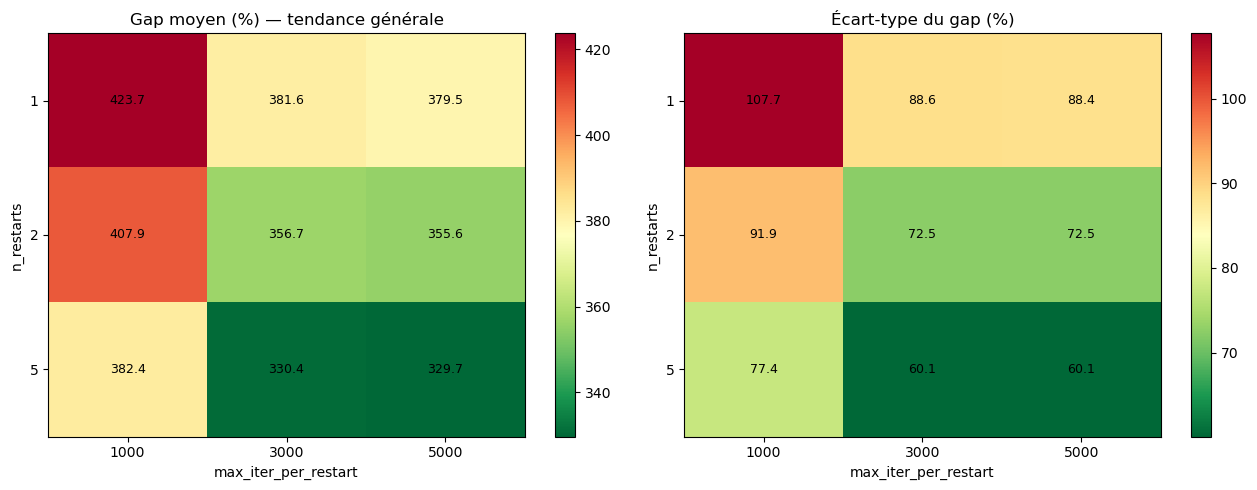

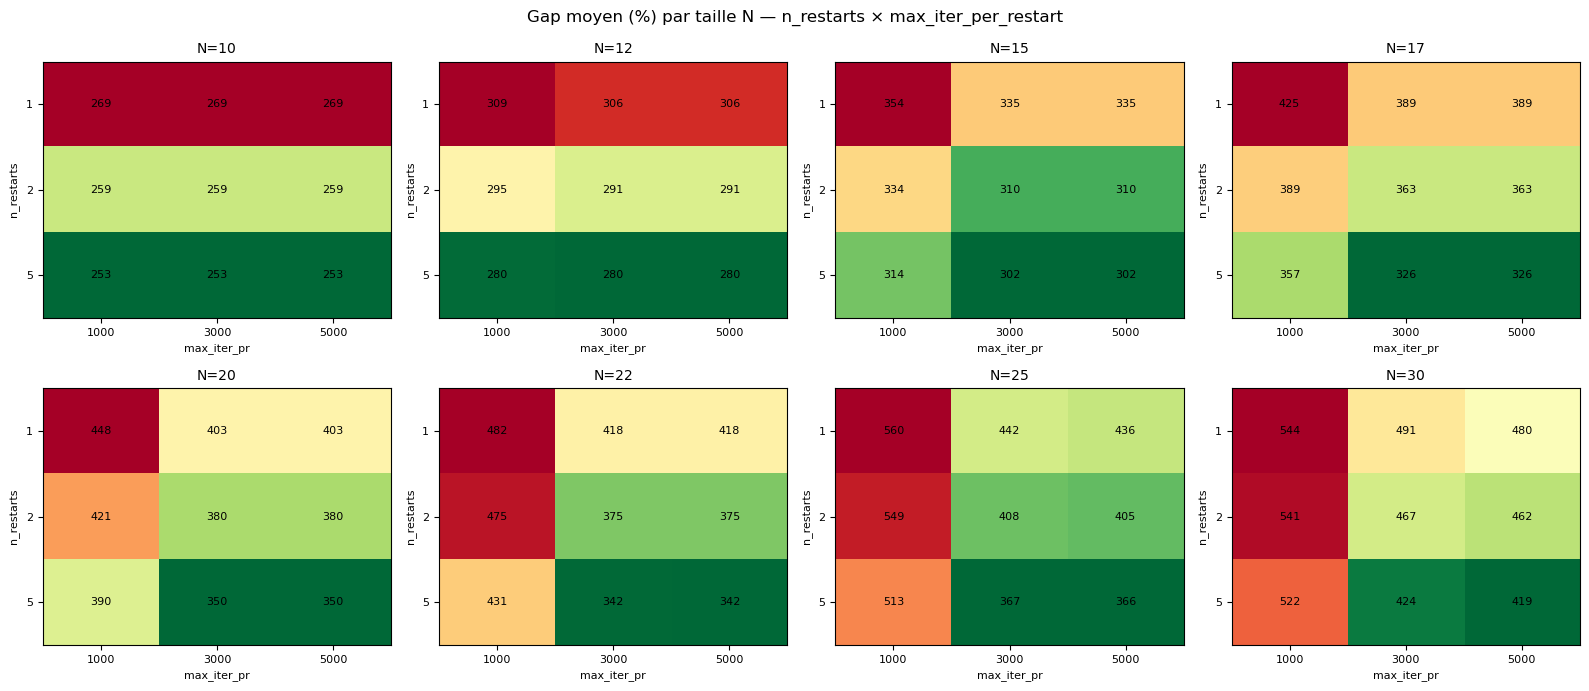

In [64]:
# Heatmap tendance générale : gap moyen agrégé sur toutes les tailles N
tendance = (
    grid_stats
    .groupby(["n_restarts", "max_iter_pr"])
    .agg(gap_mean=("gap_mean", "mean"), gap_std=("gap_std", "mean"))
    .reset_index()
)

pivot_gap = tendance.pivot(index="n_restarts", columns="max_iter_pr", values="gap_mean")
pivot_std = tendance.pivot(index="n_restarts", columns="max_iter_pr", values="gap_std")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, pivot, title in [
    (ax1, pivot_gap, "Gap moyen (%) — tendance générale"),
    (ax2, pivot_std, "Écart-type du gap (%)"),
]:
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("max_iter_per_restart")
    ax.set_ylabel("n_restarts")
    ax.set_title(title)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.1f}",
                    ha="center", va="center", color="black", fontsize=9)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Heatmap par taille N : gap moyen selon n_restarts × max_iter_pr
n_rows = 2
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 7))
axes = axes.flatten()

for ax, n in zip(axes, N_VALUES):
    sub = grid_stats[grid_stats["N"] == n]
    piv = sub.pivot(index="n_restarts", columns="max_iter_pr", values="gap_mean")
    im = ax.imshow(piv.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, fontsize=8)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index, fontsize=8)
    ax.set_xlabel("max_iter_pr", fontsize=8)
    ax.set_ylabel("n_restarts", fontsize=8)
    ax.set_title(f"N={n}", fontsize=10)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f"{piv.values[i, j]:.0f}",
                    ha="center", va="center", color="black", fontsize=8)

plt.suptitle("Gap moyen (%) par taille N — n_restarts × max_iter_per_restart", fontsize=12)
plt.tight_layout()
plt.show()

### Interprétation

Deux tendances ressortent clairement de la heatmap :

- **`n_restarts = 5` est systématiquement optimal** : la diversification améliore toujours la qualité des solutions dans la plage testée, quelle que soit la valeur de `max_iter_per_restart`.
- **`max_iter_per_restart` n'a pas d'effet pour N=10** : les valeurs 1 000, 3 000 et 5 000 donnent exactement le même gap → l'algorithme converge avant d'atteindre 1 000 itérations sur ces petits graphes. Les itérations supplémentaires sont gaspillées.
- **Pour N ≥ 17**, augmenter `max_iter_per_restart` de 1 000 à 5 000 apporte un gain mesurable (heatmap plus verte en bas à droite). Le seuil de convergence se déplace avec la taille du problème.

La heatmap de l'écart-type confirme qu'un plus grand nombre d'itérations par restart réduit la variance des solutions, signe d'une meilleure robustesse au prix d'un temps de calcul proportionnellement plus long.

## 4. Définition des paramètres optimisés

Pour chaque taille $N$, on sélectionne la combinaison `(n_restarts, max_iter_per_restart)` qui minimise `gap_mean`, départagée par `gap_std`.

In [65]:
best_per_n = (
    grid_stats
    .sort_values(["N", "gap_mean", "gap_std"])
    .groupby("N", as_index=False)
    .first()[["N", "n_restarts", "max_iter_pr", "gap_mean", "gap_std", "gap_median", "time_mean"]]
)
best_per_n

,N,n_restarts,max_iter_pr,gap_mean,gap_std,gap_median,time_mean
0,10,5,1000,253.147418,32.515635,257.286371,0.283628
1,12,5,3000,279.590034,87.415161,270.042293,0.816203
2,15,5,3000,302.008300,64.211791,322.931034,1.102286
3,17,5,5000,326.255230,39.635568,331.761549,1.891972
4,20,5,3000,349.565168,76.419605,349.149806,1.286724
5,22,5,5000,341.668996,72.319652,321.044993,2.077473
6,25,5,5000,366.498498,52.260543,359.233819,2.538160
7,30,5,5000,418.537582,56.355110,434.355473,3.001813


In [66]:
final_df = grid_df_valid.merge(
    best_per_n[["N", "n_restarts", "max_iter_pr"]],
    on=["N", "n_restarts", "max_iter_pr"],
    how="inner",
)
print(f"{len(final_df)} runs retenus (sur {len(grid_df)} au total)")

192 runs retenus (sur 2160 au total)


In [67]:
final_stats = (
    final_df
    .groupby("N")
    .agg(
        cost_best=("cost", "min"),
        cost_mean=("cost", "mean"),
        cost_median=("cost", "median"),
        cost_std=("cost", "std"),
        cost_min=("cost", "min"),
        cost_max=("cost", "max"),
        gap_mean=("gap", "mean"),
        gap_std=("gap", "std"),
        feas_rate=("feasible", "mean"),
        time_mean=("time_sec", "mean"),
        n_runs=("run", "count"),
    )
    .reset_index()
    .merge(best_per_n[["N", "n_restarts", "max_iter_pr"]], on="N")
)
cols = [
    "N", "n_restarts", "max_iter_pr",
    "cost_best", "cost_mean", "cost_median", "cost_std", "cost_min", "cost_max",
    "gap_mean", "gap_std", "feas_rate", "time_mean", "n_runs",
]
final_stats = final_stats[cols]
final_stats

,N,n_restarts,max_iter_pr,cost_best,cost_mean,cost_median,cost_std,cost_min,cost_max,gap_mean,gap_std,feas_rate,time_mean,n_runs
0,10,5,1000,31.80,39.750000,38.775,5.784049,31.80,50.10,253.147418,32.515635,1.0,0.283628,24
1,12,5,3000,27.90,43.587500,40.950,10.931797,27.90,63.45,279.590034,87.415161,1.0,0.816203,24
2,15,5,3000,34.95,43.097917,42.225,7.360891,34.95,57.00,302.008300,64.211791,1.0,1.102286,24
3,17,5,5000,30.90,42.439583,41.100,10.479638,30.90,69.60,326.255230,39.635568,1.0,1.891972,24
4,20,5,3000,32.55,45.306250,45.075,9.405795,32.55,67.65,349.565168,76.419605,1.0,1.286724,24
5,22,5,5000,24.15,44.231250,45.825,9.747774,24.15,60.30,341.668996,72.319652,1.0,2.077473,24
6,25,5,5000,33.15,47.270833,47.250,7.972383,33.15,60.60,366.498498,52.260543,1.0,2.538160,24
7,30,5,5000,42.30,54.375000,54.150,6.332679,42.30,63.75,418.537582,56.355110,1.0,3.001813,24


### Interprétation

`n_restarts = 5` est sélectionné pour **toutes les tailles** sans exception. `max_iter_per_restart` optimal croît avec N :

| Taille N | max_iter optimal | Gap moyen (%) | Temps/run (s) |
|---|---|---|---|
| 10 | 1 000 | 253 | 0,28 |
| 12–15 | 3 000 | 280–302 | 0,82–1,10 |
| 17–30 | 5 000 | 326–419 | 1,89–3,00 |

**Comparaison avec le recuit simple** (α=0.999, 10 000 iter) : pour N=30, le multi-start obtient un gap de ~419% contre ~434% pour le recuit simple, soit un gain d'environ **15 points**. Ce gain est obtenu avec une variance plus faible — le multi-start est plus robuste car il explore plusieurs bassins d'attraction indépendants.

## 5. Statistiques qualité des solutions

Résumé statistique par taille $N$ avec les meilleurs paramètres identifiés en section 4. Les runs infaisables sont exclus.

In [68]:
display_cols = {
    "N": "N",
    "n_restarts": "Restarts",
    "max_iter_pr": "Iter/restart",
    "cost_min": "Coût min",
    "cost_mean": "Coût moy.",
    "cost_median": "Coût méd.",
    "cost_std": "Écart-type",
    "cost_max": "Coût max",
    "gap_mean": "Gap moy. (%)",
    "gap_std": "Gap σ (%)",
    "feas_rate": "Faisabilité",
    "n_runs": "Runs",
}
display_df = final_stats[list(display_cols.keys())].rename(columns=display_cols)
styled = (
    display_df.style
    .format({
        "Coût min": "{:.2f}", "Coût moy.": "{:.2f}", "Coût méd.": "{:.2f}",
        "Écart-type": "{:.2f}", "Coût max": "{:.2f}",
        "Gap moy. (%)": "{:.1f}", "Gap σ (%)": "{:.1f}",
        "Faisabilité": "{:.0%}",
    })
    .background_gradient(subset=["Gap moy. (%)"], cmap="RdYlGn_r")
    .set_caption("Statistiques qualité — recuit simulé multi-start (meilleurs paramètres par N)")
    .set_table_styles([{"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold")]}])
)
display(styled)

total_valid = grid_df_valid.shape[0]
total_all = grid_df.shape[0]
print(f"\nRuns infaisables exclus : {total_all - total_valid}/{total_all} ({100*(1-total_valid/total_all):.1f}%)")

,N,Restarts,Iter/restart,Coût min,Coût moy.,Coût méd.,Écart-type,Coût max,Gap moy. (%),Gap σ (%),Faisabilité,Runs
0,10,5,1000,31.80,39.75,38.77,5.78,50.10,253.1,32.5,100%,24
1,12,5,3000,27.90,43.59,40.95,10.93,63.45,279.6,87.4,100%,24
2,15,5,3000,34.95,43.10,42.22,7.36,57.00,302.0,64.2,100%,24
3,17,5,5000,30.90,42.44,41.10,10.48,69.60,326.3,39.6,100%,24
4,20,5,3000,32.55,45.31,45.07,9.41,67.65,349.6,76.4,100%,24
5,22,5,5000,24.15,44.23,45.83,9.75,60.30,341.7,72.3,100%,24
6,25,5,5000,33.15,47.27,47.25,7.97,60.60,366.5,52.3,100%,24
7,30,5,5000,42.30,54.38,54.15,6.33,63.75,418.5,56.4,100%,24



Runs infaisables exclus : 435/2160 (20.1%)


### Interprétation

- **Faisabilité 100%** sur les runs retenus : les 20,1% de runs infaisables exclus sont une propriété structurelle des instances (contraintes de précédence + arêtes interdites), indépendante des paramètres de l'algorithme.
- Le gap moyen reste élevé (253%–419%) avec une variabilité notable. Les fortes dispersions pour N=12 (σ=87%) et N=20 (σ=76%) signalent des instances très disparates : certaines sont beaucoup plus contraintes que d'autres à l'intérieur d'une même taille.
- Les coûts minimaux observés (ex. 24,15 pour N=22) montrent que de très bonnes solutions existent, mais leur obtention n'est pas garantie sur une seule exécution — ce qui justifie l'approche multi-start.

## 6. Distance à la borne inférieure

Évolution du gap moyen (en %) en fonction de la taille $N$, avec bande d'un écart-type, et distribution des gaps par taille (box plots).

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_37052\1703356855.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(gap_by_n, labels=N_VALUES, patch_artist=True)


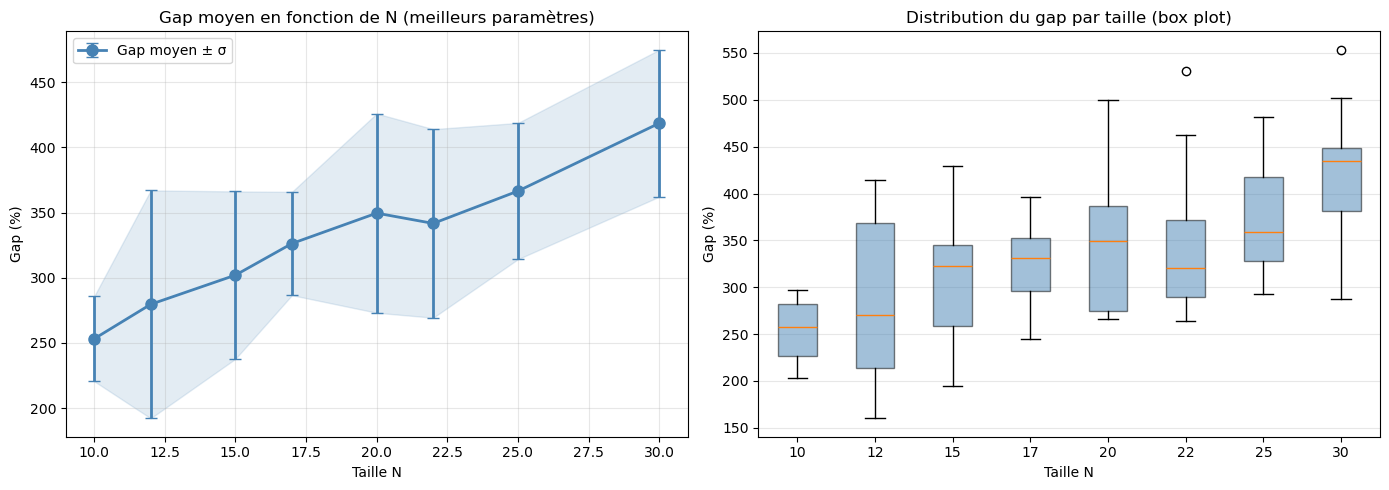

In [69]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.errorbar(
    final_stats["N"], final_stats["gap_mean"], yerr=final_stats["gap_std"],
    marker="o", capsize=4, color="steelblue", linewidth=2, markersize=8, label="Gap moyen ± σ",
)
ax1.fill_between(
    final_stats["N"],
    final_stats["gap_mean"] - final_stats["gap_std"],
    final_stats["gap_mean"] + final_stats["gap_std"],
    alpha=0.15, color="steelblue",
)
ax1.set_xlabel("Taille N")
ax1.set_ylabel("Gap (%)")
ax1.set_title("Gap moyen en fonction de N (meilleurs paramètres)")
ax1.legend()
ax1.grid(True, alpha=0.3)

gap_by_n = [final_df[final_df["N"] == n]["gap"].values for n in N_VALUES]
bp = ax2.boxplot(gap_by_n, labels=N_VALUES, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.5)
ax2.set_xlabel("Taille N")
ax2.set_ylabel("Gap (%)")
ax2.set_title("Distribution du gap par taille (box plot)")
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

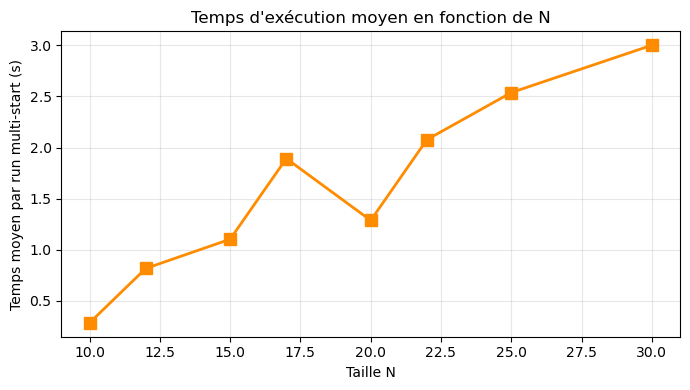

In [70]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(final_stats["N"], final_stats["time_mean"],
        marker="s", color="darkorange", linewidth=2, markersize=8)
ax.set_xlabel("Taille N")
ax.set_ylabel("Temps moyen par run multi-start (s)")
ax.set_title("Temps d'exécution moyen en fonction de N")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation

- Le gap moyen croît quasi-linéairement de **253% (N=10)** à **419% (N=30)**, reflétant la combinatoire croissante du TSP contraint. Cette progression est légèrement inférieure à celle du recuit simple (~434% à N=30), confirmant l'apport marginal du multi-start.
- La dispersion (barres d'erreur + box plots) s'élargit avec N : certains graphes deviennent nettement plus difficiles à résoudre que d'autres à mesure que N augmente.
- Le temps d'exécution par run multi-start est raisonnable : **0,28 s (N=10)** à **3,0 s (N=30)** pour 5 restarts × 5 000 itérations. Le surcoût d'un facteur ×5 par rapport au recuit simple est justifié par le gain en robustesse et la réduction de variance.

## 7. Conclusion

### Paramètres optimisés retenus

| Taille N | n_restarts | max_iter_per_restart | Gap moyen (%) | Temps/run (s) |
|---|---|---|---|---|
| 10 | 5 | 1 000 | 253 | 0,28 |
| 12–15 | 5 | 3 000 | 280–302 | 0,82–1,10 |
| 17–30 | 5 | 5 000 | 326–419 | 1,89–3,00 |

- **`n_restarts = 5`** est optimal pour toutes les tailles : la diversification reste toujours bénéfique dans la plage testée.
- **`max_iter_per_restart`** doit croître avec N pour garantir la convergence de chaque run individuel.
- **`alpha = 0.995`** fixé d'après l'expérience mono-run.

### Observations générales

- Le gap augmente de ~253% (N=10) à ~419% (N=30) — progression quasi-linéaire.
- **20,1% des runs sont infaisables** : taux stable, propriété des instances et non des paramètres.
- L'effet « escalier descendant » montre que les 2–3 premiers restarts apportent l'essentiel de l'amélioration ; les gains s'amenuisent ensuite rapidement.
- Le multi-start améliore le recuit simple d'environ **10–15 points de gap** sur les grandes tailles, au prix d'un facteur ×5 sur le temps de calcul.

### Bilan profondeur vs diversification

Avec un budget fixé, la diversification (plusieurs restarts) l'emporte sur la profondeur (un seul long run) **dès que chaque restart dispose d'assez d'itérations pour converger** (≥ 1 000 iter pour N ≤ 15, ≥ 2 000 pour N ≥ 17). En dessous de ce seuil, les restarts trop courts se comportent comme des marches aléatoires sans convergence utile.

### Réglages pour ajuster le temps de calcul

| Paramètre | Impact |
|---|---|
| `NB_ITERATIONS` | Linéaire sur le nombre de runs |
| `NB_SEEDS` | Linéaire sur le nombre de runs |
| `N_RESTARTS_VALUES` | Linéaire sur le temps par configuration |
| `MAX_ITER_PER_RESTART_VALUES` | Linéaire sur le temps par restart |

**Pour accélérer** : réduire `NB_ITERATIONS = 1` ou limiter `N_RESTARTS_VALUES = [1, 5]`.  
**Pour affiner** : tester `N_RESTARTS_VALUES = [5, 10, 20]` avec `MAX_ITER_PER_RESTART_VALUES = [2000, 5000]`.